[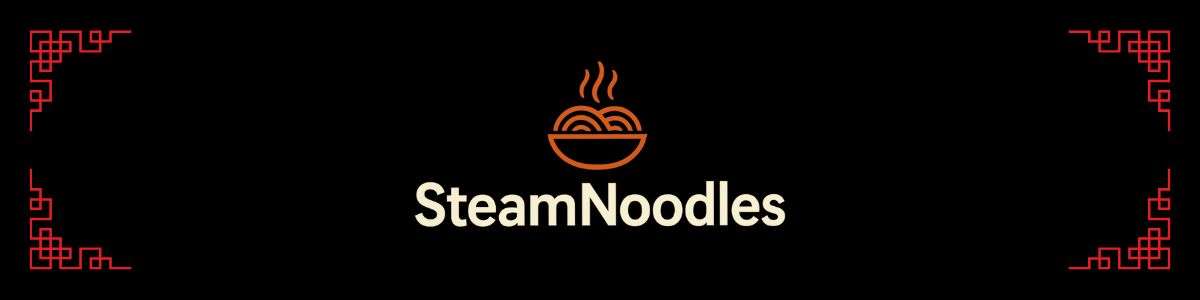](https://github.com/lenoshz/steamnoodles-feedback-agent-thejan)

# **SteamNoodles Restaurant Feedback Agent System🍜**

An AI-powered system for analyzing customer feedback and visualizing sentiment trends for the SteamNoodles restaurant chain.

**Developer:** [THEJAN WIJESINGHE](https://github.com/lenoshz)

## **🥢 Overview**

This notebook implements a complete feedback analysis system with two intelligent agents:

1. **Customer Feedback Response Agent**: Analyzes sentiment and generates personalized responses
2. **Sentiment Visualization Agent**: Creates visualizations of sentiment trends over time

The system is designed to work both online (using GROQ API) and offline (using rule-based analysis), ensuring functionality regardless of API availability.

Each agent will be implemented in its own section below.

## **⚡Setup and Dependencies**

First, let's install and import the necessary libraries.

In [ ]:
# Install required packages
!pip install langchain-groq langchain pandas matplotlib seaborn python-dateutil tqdm python-dotenv ipywidgets

In [ ]:
# Set your GROQ API key (if you have one)
import os
os.environ["GROQ_API_KEY"] = "your-api-key-here"  # Replace with your actual key

👉 If you don't have one get it from [here](https://console.groq.com/keys).

In [ ]:
# Import libraries
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import re
from dateutil.parser import parse
import json
from dotenv import load_dotenv
import warnings

# Set visualization style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = [12, 6]
warnings.filterwarnings('ignore')

# Load environment variables
load_dotenv()

# Check if GROQ API key is available
api_key = os.getenv("GROQ_API_KEY")
use_api = api_key is not None and len(api_key) > 0

print(f"GROQ API {'is available' if use_api else 'is not available - will use rule-based approach'}")

## 📊 **Data Loading and Preparation**

Let's load our restaurant review dataset. If a local dataset is not available, we'll generate synthetic data for demonstration purposes.

In [ ]:
def generate_synthetic_reviews(num_days=30, reviews_per_day_range=(5, 15)):
    """Generate synthetic restaurant reviews for demonstration"""
    # Use the provided current date (2025-08-16) as the end date
    end_date = datetime(2025, 8, 16, 19, 45, 1)
    start_date = end_date - timedelta(days=num_days)

    # Sample reviews
    positive_reviews = [
        "The food was delicious! The noodles were perfectly cooked and the service was excellent.",
        "Best restaurant experience in months. The staff was friendly and attentive.",
        "Amazing flavors in every dish. Will definitely be back again!",
        "The chef's special noodles were out of this world. Great atmosphere too.",
        "Fast service, delicious food, and reasonable prices. Highly recommended!",
        "The noodle soup was perfect for a cold day. The staff made us feel welcome.",
        "Excellent experience from start to finish. The menu has great variety.",
        "The taste was authentic and portion sizes were generous. Worth every penny!",
        "Outstanding service and the food was exceptional. Love their steam buns!",
        "A hidden gem! The flavors were complex and everything tasted fresh."
    ]

    negative_reviews = [
        "Disappointing experience. The noodles were overcooked and the service was slow.",
        "Would not recommend. Waited over 40 minutes for our food.",
        "The food was bland and not worth the price.",
        "Poor service and mediocre food. Won't be returning.",
        "The restaurant was too noisy and the food was nothing special.",
        "Had to send my dish back because it was cold. Very disappointed.",
        "Overpriced for what you get. Better options elsewhere.",
        "The staff seemed uninterested and the food was below average.",
        "Not impressed with the food quality. Expected much better.",
        "The restaurant was dirty and the food was not fresh."
    ]

    neutral_reviews = [
        "The food was okay, nothing special but not bad either.",
        "Average experience. The service was fine and food was decent.",
        "Reasonable prices but the menu is limited.",
        "The atmosphere was nice but the food was just standard.",
        "It was an okay meal. Might try it again, might not.",
        "Some dishes were good, others were mediocre.",
        "The service was quick but the food was just average.",
        "Not bad for a quick meal, but wouldn't make a special trip.",
        "Decent food but the portions were smaller than expected.",
        "The restaurant was clean and the food came out quickly, but taste was just okay."
    ]

    data = []
    current_date = start_date

    while current_date <= end_date:
        # Generate reviews for this day
        num_reviews = np.random.randint(*reviews_per_day_range)

        for _ in range(num_reviews):
            # Randomly choose sentiment with different probabilities
            sentiment = np.random.choice(
                ['positive', 'negative', 'neutral'],
                p=[0.5, 0.2, 0.3]  # 50% positive, 20% negative, 30% neutral
            )

            # Select a random review text based on sentiment
            if sentiment == 'positive':
                text = np.random.choice(positive_reviews)
            elif sentiment == 'negative':
                text = np.random.choice(negative_reviews)
            else:
                text = np.random.choice(neutral_reviews)

            # Add some randomness to the timestamp within the day
            hours = np.random.randint(9, 22)  # Between 9am and 10pm
            minutes = np.random.randint(0, 60)
            seconds = np.random.randint(0, 60)
            timestamp = current_date.replace(hour=hours, minute=minutes, second=seconds)

            data.append({
                'date': timestamp,
                'text': text,
                'sentiment': sentiment
            })

        current_date += timedelta(days=1)

    # Create DataFrame and sort by date
    return pd.DataFrame(data).sort_values('date')

# Try to load dataset from file, or generate synthetic data
try:
    # Attempt to load from a CSV file if it exists
    df = pd.read_csv('restaurant_reviews.csv')
    df['date'] = pd.to_datetime(df['date'])
    print(f"Loaded {len(df)} reviews from CSV file")
except FileNotFoundError:
    # Generate synthetic data if file doesn't exist
    df = generate_synthetic_reviews()
    print(f"Generated {len(df)} synthetic reviews for demonstration")

# Display the first few rows of the dataset
df.head()

### 🔎 Review Dataset Overview

Let's examine our dataset to understand what we're working with.

In [ ]:
# Print dataset statistics
print("Dataset Overview:")
print(f"Number of reviews: {len(df)}")
print(f"Date range: {df['date'].min().date()} to {df['date'].max().date()}")
print("\nSentiment distribution:")
sentiment_counts = df['sentiment'].value_counts()
for sentiment, count in sentiment_counts.items():
    percentage = (count / len(df)) * 100
    print(f"- {sentiment}: {count} reviews ({percentage:.1f}%)")

# Plot sentiment distribution as a pie chart with specific colors
colors = {
    'positive': "#1f77b4",  # Blue
    'negative': "#ff7f0e",  # Orange
    'neutral': "#2ca02c"   # Green
}
# Ensure the order of sentiments for plotting
ordered_sentiments = ['positive', 'negative', 'neutral']
ordered_counts = sentiment_counts.reindex(ordered_sentiments)
ordered_colors = [colors[s] for s in ordered_sentiments]


plt.figure(figsize=(8, 8))
plt.pie(ordered_counts, labels=ordered_counts.index, autopct='%1.1f%%', startangle=90, colors=ordered_colors)
plt.title("Overall Sentiment Distribution", fontsize=16)
plt.axis('equal')
plt.show()

## 🥇 **Agent 1: Customer Feedback Response Agent**

This agent analyzes customer feedback, determines sentiment, identifies topics mentioned, and generates personalized responses.

The system is designed to work in two modes:
1. **API Mode**: Uses GROQ LLM for sophisticated analysis (when API key is available)
2. **Offline Mode**: Uses rule-based analysis (as fallback when no API is available)

In [ ]:
class RuleBasedFeedbackAgent:
    """Rule-based implementation of feedback response agent"""

    def __init__(self):
        # Sentiment-related keywords
        self.positive_words = [
            "good", "great", "excellent", "amazing", "delicious", "tasty",
            "enjoyed", "wonderful", "fantastic", "perfect", "best", "love",
            "fresh", "friendly", "helpful", "recommend", "clean", "impressive"
        ]

        self.negative_words = [
            "bad", "poor", "terrible", "awful", "horrible", "disappointing",
            "overpriced", "cold", "slow", "rude", "dirty", "unclean", "wait",
            "mistake", "wrong", "bland", "tasteless", "undercooked", "overcooked"
        ]

        # Topic-related keywords
        self.topics = {
            "food": ["food", "meal", "noodle", "dish", "taste", "flavor", "spicy", "menu"],
            "service": ["service", "staff", "waiter", "waitress", "server", "employee"],
            "cleanliness": ["clean", "dirty", "table", "floor", "bathroom"],
            "ambiance": ["atmosphere", "ambiance", "noise", "music", "decor"],
            "price": ["price", "expensive", "cheap", "value", "cost"]
        }

    def analyze_sentiment(self, text):
        """Determine sentiment using keyword matching"""
        text = text.lower()

        # Count positive and negative words
        positive_count = sum(1 for word in self.positive_words if word in text)
        negative_count = sum(1 for word in self.negative_words if word in text)

        if positive_count > negative_count:
            return "positive"
        elif negative_count > positive_count:
            return "negative"
        else:
            return "neutral"

    def detect_topics(self, text):
        """Detect topics mentioned in the text"""
        text = text.lower()
        detected_topics = []

        for topic, keywords in self.topics.items():
            if any(keyword in text for keyword in keywords):
                detected_topics.append(topic)

        return detected_topics

    def generate_response(self, text):
        """Generate a response based on sentiment and topics"""
        sentiment = self.analyze_sentiment(text)
        topics = self.detect_topics(text)

        # Start with greeting
        response = "Thank you for sharing your feedback with SteamNoodles. "

        # Add sentiment-specific content
        if sentiment == "positive":
            response += "We're delighted to hear that you enjoyed your experience! "

            # Add topic-specific responses
            if "food" in topics:
                response += "We're glad you enjoyed our cuisine. Our chefs will be happy to hear your praise. "
            if "service" in topics:
                response += "Thank you for recognizing our staff's efforts. We take pride in providing excellent service. "
            if "cleanliness" in topics:
                response += "We're pleased that you noticed our dedication to maintaining a clean environment. "
            if "ambiance" in topics:
                response += "We're happy that you appreciated the atmosphere we've created. "
            if "price" in topics:
                response += "We strive to provide excellent value and we're glad you found our pricing reasonable. "

            response += "We hope to welcome you back soon!"

        elif sentiment == "negative":
            response += "We sincerely apologize for not meeting your expectations. "

            # Add topic-specific responses
            if "food" in topics:
                response += "We're sorry about your experience with our food. We'll share your feedback with our culinary team for improvement. "
            if "service" in topics:
                response += "We apologize for the service issues you encountered. We're committed to better training our staff. "
            if "cleanliness" in topics:
                response += "We're truly sorry about the cleanliness concerns you mentioned. We're addressing this immediately with our team. "
            if "ambiance" in topics:
                response += "We regret that the atmosphere didn't meet your expectations and we're working to improve it. "
            if "price" in topics:
                response += "We're sorry you felt our pricing didn't match the value received. We're reviewing our offerings to ensure better value. "

            response += "Your feedback helps us improve, and we hope you'll give us another opportunity to serve you better."

        else:  # neutral
            response += "We appreciate you taking the time to share your thoughts. "

            if topics:
                response += f"Thank you for your comments about {', '.join(topics)}. "

            response += "We hope to see you again at SteamNoodles!"

        return {
            "sentiment": sentiment,
            "topics": topics,
            "response": response
        }

# Create API-based agent if API key is available
if use_api:
    from langchain_groq import ChatGroq
    from langchain_core.prompts import ChatPromptTemplate

    class APIFeedbackAgent:
        """GROQ API-based implementation of feedback response agent"""

        def __init__(self, api_key):
            self.model = ChatGroq(
                api_key=api_key,
                model_name="llama3-8b-8192"
            )

            # Create the prompt template
            self.prompt = ChatPromptTemplate.from_template("""
            You are an AI assistant for SteamNoodles restaurant chain. Analyze this customer feedback
            and provide a JSON response with sentiment analysis and a personalized reply.

            Customer Feedback: {feedback}

            Your response should be professional, acknowledge specific aspects mentioned,
            and show genuine care for the customer's experience.

            Respond with a JSON object containing:
            - sentiment: The sentiment (positive, negative, or neutral)
            - topics: Array of topics mentioned (food, service, cleanliness, ambiance, price)
            - response: Your personalized response to the customer
            """)

        def _extract_json(self, text):
            """Extract JSON from the model output"""
            try:
                # Try to find JSON pattern in the text
                json_match = re.search(r'({[\s\S]*})', text)
                if json_match:
                    json_str = json_match.group(1)
                    return json.loads(json_str)
            except json.JSONDecodeError:
                pass

            # Fallback to rule-based agent if JSON extraction fails
            fallback_agent = RuleBasedFeedbackAgent()
            return fallback_agent.generate_response(text)

        def generate_response(self, text):
            """Generate a response using the GROQ API"""
            try:
                result = self.model.invoke(self.prompt.format(feedback=text))
                return self._extract_json(result.content)
            except Exception as e:
                print(f"API Error: {str(e)}")
                # Fallback to rule-based agent on error
                fallback_agent = RuleBasedFeedbackAgent()
                return fallback_agent.generate_response(text)

# Choose which agent to use based on API availability
if use_api:
    feedback_agent = APIFeedbackAgent(api_key)
    print("Using GROQ API-based feedback agent")
else:
    feedback_agent = RuleBasedFeedbackAgent()
    print("Using rule-based feedback agent (no API)")

### **🧪 Test the Feedback Response Agent**

Let's test our feedback response agent with some sample customer reviews.

In [ ]:
def display_feedback_analysis(feedback, result):
    """Display the feedback analysis results in a formatted way"""
    print("\033[1mCustomer Feedback:\033[0m")
    print(f"{feedback}")
    print("\n\033[1mAnalysis Results:\033[0m")
    print(f"Sentiment: {result['sentiment']}")
    if 'topics' in result:
        topics = result['topics'] if result['topics'] else ['None detected']
        print(f"Topics: {', '.join(topics)}")
    print("\n\033[1mAutomated Response:\033[0m")
    print(f"{result['response']}")
    print("\n" + "-"*80)

# Test with different types of feedback
test_feedbacks = [
    "The noodles were amazing and the service was exceptional! Will definitely come back.",
    "Food was cold and we waited over 30 minutes. The server was not attentive at all.",
    "The restaurant was okay. Food was decent but nothing special."
]

for feedback in test_feedbacks:
    result = feedback_agent.generate_response(feedback)
    display_feedback_analysis(feedback, result)

### 🔬 **Interactive Feedback Analysis**

Now let's create an interactive cell where you can enter your own feedback text for analysis.

In [ ]:
from IPython.display import display, HTML
import ipywidgets as widgets

# Create text input and button widgets
feedback_input = widgets.Textarea(
    value='',
    placeholder='Enter customer feedback here...',
    description='Feedback:',
    disabled=False,
    layout=widgets.Layout(width='80%', height='100px')
)

analyze_button = widgets.Button(
    description='Analyze Feedback',
    button_style='primary',
    tooltip='Click to analyze the feedback'
)

output_area = widgets.Output()

def on_analyze_button_clicked(b):
    with output_area:
        output_area.clear_output()
        feedback_text = feedback_input.value
        if not feedback_text.strip():
            print("Please enter some feedback text.")
            return

        result = feedback_agent.generate_response(feedback_text)
        display_feedback_analysis(feedback_text, result)

analyze_button.on_click(on_analyze_button_clicked)

# Display the widgets
display(HTML("<h3>Interactive Feedback Analyzer</h3>"))
display(feedback_input)
display(analyze_button)
display(output_area)

## 🥈 **Agent 2: Sentiment Visualization Agent**

This agent generates visualizations of sentiment trends across specified date ranges using natural language date queries.

In [ ]:
class SentimentVisualizationAgent:
    """Agent for creating visualizations of sentiment trends"""

    def __init__(self, data):
        self.data = data

    def parse_date_range(self, text):
        """Parse natural language date range"""
        today = datetime(2025, 8, 16)  # Use current date from context

        # Handle "last X days"
        if match := re.search(r"last\s+(\d+)\s+days", text.lower()):
            days = int(match.group(1))
            return today - timedelta(days=days), today

        # Handle "this week"
        elif "this week" in text.lower():
            start_date = today - timedelta(days=today.weekday())
            return start_date, today

        # Handle "this month"
        elif "this month" in text.lower():
            start_date = today.replace(day=1)
            return start_date, today

        # Handle date range "X to Y"
        elif " to " in text:
            parts = text.split(" to ")
            try:
                start_date = parse(parts[0], fuzzy=True)
                end_date = parse(parts[1], fuzzy=True)
                return start_date, end_date
            except:
                pass

        # Default to last 7 days
        return today - timedelta(days=7), today

    def generate_daily_sentiment_chart(self, date_range_text):
        """Generate a bar chart of daily sentiment counts"""
        # Parse the date range
        start_date, end_date = self.parse_date_range(date_range_text)

        # Format dates for display
        start_str = start_date.strftime("%Y-%m-%d")
        end_str = end_date.strftime("%Y-%m-%d")

        # Filter the data
        filtered_data = self.data[
            (self.data['date'] >= start_date) &
            (self.data['date'] <= end_date)
        ]

        if filtered_data.empty:
            plt.figure(figsize=(12, 6))
            plt.text(0.5, 0.5, "No data available for the selected date range",
                     ha='center', va='center', fontsize=14)
            plt.title(f"SteamNoodles — Daily Sentiment Counts ({start_str} to {end_str})",
                     fontsize=16)
            plt.tight_layout()
            return plt

        # Add a date_only column for grouping
        filtered_data['date_only'] = filtered_data['date'].dt.date

        # Group by date and sentiment
        sentiment_counts = filtered_data.groupby(['date_only', 'sentiment']).size().unstack(fill_value=0)

        # Ensure all sentiment columns exist
        for sentiment in ['positive', 'negative', 'neutral']:
            if sentiment not in sentiment_counts.columns:
                sentiment_counts[sentiment] = 0

        # Create a figure
        plt.figure(figsize=(12, 6))

        # Get the dates and positions for the bars
        dates = sentiment_counts.index
        x = np.arange(len(dates))
        width = 0.25

        # Plot each sentiment as a group of bars
        plt.bar(x - width, sentiment_counts['positive'], width, label='positive', color='#1f77b4')
        plt.bar(x, sentiment_counts['negative'], width, label='negative', color='#ff7f0e')
        plt.bar(x + width, sentiment_counts['neutral'], width, label='neutral', color='#2ca02c')

        # Set the labels and title
        plt.xlabel('Date', fontsize=12)
        plt.ylabel('Number of Reviews', fontsize=12)
        plt.title(f"SteamNoodles — Daily Sentiment Counts ({start_str} to {end_str})",
                 fontsize=16)

        # Set the x-axis ticks to dates
        plt.xticks(x, [date.strftime('%Y-%m-%d') for date in dates], rotation=45)

        # Add legend
        plt.legend(title="sentiment")

        # Adjust layout
        plt.tight_layout()

        return plt

    def generate_sentiment_trend_chart(self, date_range_text):
        """Generate a line chart of sentiment trends"""
        # Parse the date range
        start_date, end_date = self.parse_date_range(date_range_text)

        # Format dates for display
        start_str = start_date.strftime("%Y-%m-%d")
        end_str = end_date.strftime("%Y-%m-%d")

        # Filter the data
        filtered_data = self.data[
            (self.data['date'] >= start_date) &
            (self.data['date'] <= end_date)
        ]

        if filtered_data.empty:
            plt.figure(figsize=(12, 6))
            plt.text(0.5, 0.5, "No data available for the selected date range",
                     ha='center', va='center', fontsize=14)
            plt.title(f"SteamNoodles — Sentiment Trend ({start_str} to {end_str})",
                     fontsize=16)
            plt.tight_layout()
            return plt

        # Add a date_only column for grouping
        filtered_data['date_only'] = filtered_data['date'].dt.date

        # Group by date and sentiment
        sentiment_counts = filtered_data.groupby(['date_only', 'sentiment']).size().unstack(fill_value=0)

        # Ensure all sentiment columns exist
        for sentiment in ['positive', 'negative', 'neutral']:
            if sentiment not in sentiment_counts.columns:
                sentiment_counts[sentiment] = 0

        # Calculate percentages
        sentiment_pcts = sentiment_counts.div(sentiment_counts.sum(axis=1), axis=0) * 100

        # Plot as lines
        plt.figure(figsize=(12, 6))

        plt.plot(sentiment_pcts.index, sentiment_pcts['positive'], marker='o', linewidth=2, label='Positive')
        plt.plot(sentiment_pcts.index, sentiment_pcts['negative'], marker='s', linewidth=2, label='Negative')
        plt.plot(sentiment_pcts.index, sentiment_pcts['neutral'], marker='^', linewidth=2, label='Neutral')

        plt.xlabel('Date', fontsize=12)
        plt.ylabel('Percentage of Reviews', fontsize=12)
        plt.title(f"SteamNoodles — Sentiment Trend ({start_str} to {end_str})",
                 fontsize=16)

        # Format x-axis
        plt.xticks(rotation=45)
        plt.gca().xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%Y-%m-%d'))

        # Add legend
        plt.legend()

        # Add grid
        plt.grid(True, alpha=0.3)

        # Adjust layout
        plt.tight_layout()

        return plt

# Create the visualization agent
viz_agent = SentimentVisualizationAgent(df)
print("Sentiment Visualization Agent initialized")

### 🧪 **Test the Sentiment Visualization Agent**

Let's test our visualization agent with some date range examples.

In [ ]:
# Test with a specific date range
date_range = "August 1 to August 7, 2025"
viz_agent.generate_daily_sentiment_chart(date_range)

In [ ]:
# Test with "last 7 days"
viz_agent.generate_daily_sentiment_chart("last 7 days")

In [ ]:
# Also show the trend line chart
viz_agent.generate_sentiment_trend_chart("last 14 days")

### 📊 **Interactive Sentiment Visualization**

Now let's create an interactive visualization tool where you can specify a date range and see the results.

In [ ]:
# Create widgets for interactive visualization
date_range_input = widgets.Text(
    value='last 7 days',
    placeholder='Enter date range (e.g., "last 7 days" or "August 1 to August 15, 2025")',
    description='Date Range:',
    disabled=False,
    layout=widgets.Layout(width='80%')
)

chart_type = widgets.RadioButtons(
    options=['Bar Chart (Daily Counts)', 'Line Chart (Trend)'],
    value='Bar Chart (Daily Counts)',
    description='Chart Type:',
    disabled=False
)

visualize_button = widgets.Button(
    description='Generate Visualization',
    button_style='success',
    tooltip='Click to generate visualization'
)

viz_output = widgets.Output()

def on_visualize_button_clicked(b):
    with viz_output:
        viz_output.clear_output()
        date_range = date_range_input.value

        if chart_type.value == 'Bar Chart (Daily Counts)':
            viz_agent.generate_daily_sentiment_chart(date_range)
        else:  # Line chart
            viz_agent.generate_sentiment_trend_chart(date_range)

        plt.show()

visualize_button.on_click(on_visualize_button_clicked)

# Display the widgets
display(HTML("<h3>Interactive Sentiment Visualization</h3>"))
display(date_range_input)
display(chart_type)
display(visualize_button)
display(viz_output)




---


## **System Design and Technical Details**

### **Adaptive Architecture**
The SteamNoodles Feedback Agent System is designed with adaptability in mind:

1. **Dual-Mode Operation**
   - Automatically detects API availability
   - Uses GROQ LLM for enhanced analysis when available
   - Falls back to rule-based analysis when API is unavailable
   - Maintains consistent functionality across both modes

2. **Feedback Response Agent**
   - **API Mode**: Uses GROQ's LLM capabilities for nuanced sentiment analysis
   - **Rule-Based Mode**: Uses keyword matching for sentiment and topic detection
   - Both modes generate contextually appropriate, personalized responses

3. **Visualization Agent**
   - **Natural Language Date Parser**: Understands expressions like "last 7 days"
   - **Multi-Visualization Support**: Bar charts for counts, line charts for trends
   - **Interactive Controls**: Widget-based interface for exploring the data

### **Technical Implementation**

1. **Feedback Analysis**
   - Sentiment analysis classifies feedback as positive, negative, or neutral
   - Topic detection identifies key areas mentioned (food, service, cleanliness, etc.)
   - Response generation creates personalized, context-aware replies

2. **Sentiment Visualization**
   - Data filtering based on natural language date queries
   - Aggregation of sentiment data by day
   - Bar charts showing distribution of sentiments
   - Line charts showing sentiment trends over time

3. **Interactive Experience**
   - Jupyter widgets enable real-time interaction
   - Feedback can be entered and analyzed immediately
   - Visualizations update dynamically based on user input
   - All functionality accessible through an intuitive interface

## **Summary and Conclusion**

The SteamNoodles Feedback Agent System provides restaurant management with powerful tools for analyzing customer feedback and visualizing sentiment trends. By implementing these capabilities in an interactive Jupyter Notebook, we've created a system that is both powerful and accessible.

### **Key Achievements**

1. **Customer Feedback Response Agent**
   - Analyzes sentiment of customer reviews
   - Identifies specific topics mentioned in the feedback
   - Generates personalized, context-aware responses
   - Works in both online and offline modes

2. **Sentiment Visualization Agent**
   - Accepts natural language date ranges
   - Generates bar charts showing sentiment distribution by day
   - Provides trend analysis with line charts
   - Offers interactive visualization capabilities

### **Business Value**

For SteamNoodles restaurant management, this system delivers significant value:

- **Customer Insights**: Understand sentiment patterns and identify areas for improvement
- **Time Savings**: Automate the process of analyzing feedback and generating responses
- **Trend Analysis**: Visualize how sentiment changes over time to track improvements
- **Flexibility**: Work with or without API access, ensuring consistent functionality

### **Future Enhancements**

The system could be extended in several ways:

- Advanced NLP for more nuanced sentiment analysis
- Integration with actual customer database systems
- Automated alerts for negative trends
- Competitor analysis capabilities
- Multi-language support

This project demonstrates how AI and data visualization can be combined to create powerful tools for business intelligence and customer relationship management.